In [ ]:
import pathlib

In [ ]:
import marimo as mo
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
from conduitpylib.wrangle import retrieve_and_prepare_delta_dataframes

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-05-22T20:38:22.806341+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

matplotlib: 3.9.2
scipy     : 1.14.1
teeplot   : 1.4.2
numpy     : 2.1.2
pandas    : 2.2.3
seaborn   : 0.13.2
requests  : 2.34.2
marimo    : 0.23.2

```

## Prep Data

In [ ]:
for slug in "2rdj6", "9utpr":
    with open(f"/tmp/{slug}", "wb") as _fp:
        _fp.write(
            requests.get(
                f"https://osf.io/{slug}/download", allow_redirects=True
            ).content,
        )

_, df_snapshot_diffs = retrieve_and_prepare_delta_dataframes(
    df_inlet_url="/tmp/2rdj6",
    df_outlet_url="/tmp/9utpr",
)

a: df_inlet
digest: 504972c237b71fc0675d536bd6d0f6dd027e154d3660627a0f1be63209683cea
num cols: 69
num cols all na: 6
num cols any na: 22
num na: 1054851
num rows: 175232
num rows all na: 0
num rows any na: 175232
size: 176M

a: df_outlet
digest: 53aa29c5074543e3c07d36adadb600818c2872ccfc74ed63cda1df80da49f9d1
num cols: 43
num cols all na: 2
num cols any na: 12
num na: 352790
num rows: 175232
num rows all na: 0
num rows any na: 175232
size: 141M



In [ ]:
df_snapshot_diffs

,Process Instance UUID,Snapshot,Async Mode,Num Nodes,Allocated Tasks Per Node,Cpus Per Node,Num Processes,Log Num Processes,Num Simels Per Cpu,Replicate,...,Intermittancy,Bunching,"Latency, Log10 Updates",ms Per Update,"Delivery Failure, %",% Msgs Lost,Msgs Received Per Sent,Messages Received Per Second,Messages Sent Per Second,Any Messages Dropped
0,0000849e-f19d-43ad-9204-9bc8d7e45172,0,3,64,4,4,256,4.0,1,5,...,2.613298,2.613298,0.846262,0.062735,22.816383,22.816383,0.610639,10059.953744,15940.073009,True
1,0000849e-f19d-43ad-9204-9bc8d7e45172,1,3,64,4,4,256,4.0,1,5,...,2.540928,2.540928,0.915567,0.060250,25.561382,25.561382,0.526399,8701.742269,16597.603097,True
2,0000849e-f19d-43ad-9204-9bc8d7e45172,2,3,64,4,4,256,4.0,1,5,...,2.471155,2.471155,0.878122,0.060270,24.145850,24.145850,0.532378,8796.796640,16592.104217,True
3,0000849e-f19d-43ad-9204-9bc8d7e45172,3,3,64,4,4,256,4.0,1,5,...,2.366563,2.366563,0.835851,0.060039,23.180656,23.180656,0.540689,8962.631506,16655.965994,True
4,0000849e-f19d-43ad-9204-9bc8d7e45172,4,3,64,4,4,256,4.0,1,5,...,2.440901,2.440901,0.887137,0.060576,24.933080,24.933080,0.534738,8821.131015,16508.301360,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80635,ffff1ca8-a0f8-4195-a0ba-b84134b47ccc,1,3,256,1,1,16,2.0,1,6,...,4.396012,4.396012,0.900952,0.070273,0.000000,0.000000,1.091938,15463.273370,14230.186528,False
80636,ffff1ca8-a0f8-4195-a0ba-b84134b47ccc,2,3,256,1,1,16,2.0,1,6,...,5.666886,5.666886,0.972480,0.068099,0.000000,0.000000,1.025197,15506.342921,14684.407550,False
80637,ffff1ca8-a0f8-4195-a0ba-b84134b47ccc,3,3,256,1,1,16,2.0,1,6,...,3.931103,3.931103,0.859262,0.070589,0.000000,0.000000,1.086198,15311.056876,14166.558736,False
80638,ffff1ca8-a0f8-4195-a0ba-b84134b47ccc,4,3,256,1,1,16,2.0,1,6,...,5.004445,5.004445,0.946919,0.067344,0.000000,0.000000,1.027037,15173.986664,14849.165234,False


In [ ]:
df_snapshot_diffs[
    ~np.isfinite(df_snapshot_diffs["Latency Simsteps Outlet"])
    | ~np.isfinite(df_snapshot_diffs["Latency Simsteps Inlet"])
    | ~np.isfinite(df_snapshot_diffs["Delivery Failure Rate"])
    | ~np.isfinite(df_snapshot_diffs["Delivery Clumpiness"])
    | ~np.isfinite(df_snapshot_diffs["Simstep Period Outlet (ns)"])
    | ~np.isfinite(df_snapshot_diffs["Simstep Period Inlet (ns)"])
    | ~np.isfinite(df_snapshot_diffs["Latency Walltime Inlet (ns)"])
    | ~np.isfinite(df_snapshot_diffs["Latency Walltime Outlet (ns)"])
][
    [
        "Latency Simsteps Inlet",
        "Latency Simsteps Outlet",
        "Snapshot",
        "Runtime Seconds Elapsed Outlet",
        "Hostname",
        "Replicate",
        "Num Simels Per Cpu",
        "Cpus Per Node",
        "Num Processes",
    ]
]

,Latency Simsteps Inlet,Latency Simsteps Outlet,Snapshot,Runtime Seconds Elapsed Outlet,Hostname,Replicate,Num Simels Per Cpu,Cpus Per Node,Num Processes
867,NaN,NaN,3,30.5,lac-050,0,1,4,256
868,NaN,NaN,4,90.5,lac-050,0,1,4,256
869,NaN,NaN,5,150.5,lac-050,0,1,4,256
13477,NaN,inf,1,167.5,lac-188,6,1,4,256
13478,NaN,inf,2,32.5,lac-188,6,1,4,256
...,...,...,...,...,...,...,...,...,...
13481,NaN,NaN,5,212.5,lac-188,6,1,4,256
52394,NaN,NaN,2,192.5,lac-046,9,1,4,16
52395,NaN,NaN,3,252.5,lac-046,9,1,4,16
52396,NaN,NaN,4,312.5,lac-046,9,1,4,16


In [ ]:
df_snapshot_diffs["Simstep Period Inlet (ms)"] = (
    df_snapshot_diffs["Simstep Period Inlet (ns)"] / 10**6
)
df_snapshot_diffs["Latency Walltime Inlet (ms)"] = (
    df_snapshot_diffs["Latency Walltime Inlet (ns)"] / 10**6
)
df_snapshot_diffs["Simstep Period Outlet (ms)"] = (
    df_snapshot_diffs["Simstep Period Outlet (ns)"] / 10**6
)
df_snapshot_diffs["Latency Walltime Outlet (ms)"] = (
    df_snapshot_diffs["Latency Walltime Outlet (ns)"] / 10**6
)

In [ ]:
df_compare = df_snapshot_diffs[
    df_snapshot_diffs["Num Processes"].isin([64, 256])
].copy()
df_compare

,Process Instance UUID,Snapshot,Async Mode,Num Nodes,Allocated Tasks Per Node,Cpus Per Node,Num Processes,Log Num Processes,Num Simels Per Cpu,Replicate,...,"Delivery Failure, %",% Msgs Lost,Msgs Received Per Sent,Messages Received Per Second,Messages Sent Per Second,Any Messages Dropped,Simstep Period Inlet (ms),Latency Walltime Inlet (ms),Simstep Period Outlet (ms),Latency Walltime Outlet (ms)
0,0000849e-f19d-43ad-9204-9bc8d7e45172,0,3,64,4,4,256,4.0,1,5,...,22.816383,22.816383,0.610639,10059.953744,15940.073009,True,0.062735,0.440323,0.060700,0.467380
1,0000849e-f19d-43ad-9204-9bc8d7e45172,1,3,64,4,4,256,4.0,1,5,...,25.561382,25.561382,0.526399,8701.742269,16597.603097,True,0.060250,0.496046,0.060493,0.491360
2,0000849e-f19d-43ad-9204-9bc8d7e45172,2,3,64,4,4,256,4.0,1,5,...,24.145850,24.145850,0.532378,8796.796640,16592.104217,True,0.060270,0.455219,0.060520,0.450850
3,0000849e-f19d-43ad-9204-9bc8d7e45172,3,3,64,4,4,256,4.0,1,5,...,23.180656,23.180656,0.540689,8962.631506,16655.965994,True,0.060039,0.411422,0.060327,0.407301
4,0000849e-f19d-43ad-9204-9bc8d7e45172,4,3,64,4,4,256,4.0,1,5,...,24.933080,24.933080,0.534738,8821.131015,16508.301360,True,0.060576,0.467127,0.060620,0.464731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80629,fff2a71f-23df-483e-93b1-b57c3609e63d,1,3,64,4,4,256,4.0,2048,5,...,-0.244545,-0.244545,1.074527,685.505741,639.124295,True,1.564915,1.957323,1.567495,1.954473
80630,fff2a71f-23df-483e-93b1-b57c3609e63d,2,3,64,4,4,256,4.0,2048,5,...,0.013089,0.013089,1.092614,706.199741,639.086409,True,1.564620,1.616648,1.547174,1.606547
80631,fff2a71f-23df-483e-93b1-b57c3609e63d,3,3,64,4,4,256,4.0,2048,5,...,0.018901,0.018901,1.089272,705.258739,638.688350,True,1.565641,1.653482,1.544500,1.642591
80632,fff2a71f-23df-483e-93b1-b57c3609e63d,4,3,64,4,4,256,4.0,2048,5,...,0.060577,0.060577,1.092805,702.045236,637.478131,True,1.568567,1.631443,1.556601,1.616309


In [ ]:
data_median = (
    df_compare.copy()
    .groupby(
        [
            "Execution Instance UUID",
        ]
    )
    .median(numeric_only=True)
    .reset_index()
    .astype(
        {
            "Num Processes": "int64",
            "Allocated Tasks Per Node": "int64",
            "Cpus Per Node": "int64",
            "Num Simels Per Cpu": "int64",
        }
    )[
        [
            "Num Processes",
            "Cpus Per Node",
            "Num Simels Per Cpu",
            "Latency Simsteps Outlet",
            "Delivery Failure Rate",
            "Delivery Clumpiness",
            "Simstep Period Outlet (ms)",
            "Latency Walltime Outlet (ms)",
        ]
    ]
    .melt(
        id_vars=[
            "Num Processes",
            "Cpus Per Node",
            "Num Simels Per Cpu",
        ],
        var_name="Metric",
        value_name="Value",
    )
)

data_median["Kind"] = "median"
data_median

,Num Processes,Cpus Per Node,Num Simels Per Cpu,Metric,Value,Kind
0,64,4,2048,Latency Simsteps Outlet,1.393651,median
1,256,4,1,Latency Simsteps Outlet,5.586443,median
2,64,4,2048,Latency Simsteps Outlet,1.382971,median
3,256,1,2048,Latency Simsteps Outlet,1.201325,median
4,256,1,1,Latency Simsteps Outlet,5.627102,median
...,...,...,...,...,...,...
395,256,1,1,Latency Walltime Outlet (ms),0.484064,median
396,256,4,1,Latency Walltime Outlet (ms),0.438310,median
397,64,1,1,Latency Walltime Outlet (ms),0.454265,median
398,256,1,2048,Latency Walltime Outlet (ms),2.295935,median


In [ ]:
data_max = (
    df_compare.copy()
    .groupby(
        [
            "Execution Instance UUID",
        ]
    )
    .max(numeric_only=True)
    .reset_index()
    .astype(
        {
            "Num Processes": "int64",
            "Allocated Tasks Per Node": "int64",
            "Cpus Per Node": "int64",
            "Num Simels Per Cpu": "int64",
        }
    )[
        [
            "Num Processes",
            "Cpus Per Node",
            "Num Simels Per Cpu",
            "Latency Simsteps Outlet",
            "Delivery Failure Rate",
            "Delivery Clumpiness",
            "Simstep Period Outlet (ms)",
            "Latency Walltime Outlet (ms)",
        ]
    ]
    .melt(
        id_vars=[
            "Num Processes",
            "Cpus Per Node",
            "Num Simels Per Cpu",
        ],
        var_name="Metric",
        value_name="Value",
    )
)

data_max["Kind"] = "max"
data_max

,Num Processes,Cpus Per Node,Num Simels Per Cpu,Metric,Value,Kind
0,64,4,2048,Latency Simsteps Outlet,2.428131e+00,max
1,256,4,1,Latency Simsteps Outlet,3.377627e+01,max
2,64,4,2048,Latency Simsteps Outlet,3.896263e+00,max
3,256,1,2048,Latency Simsteps Outlet,1.488600e+03,max
4,256,1,1,Latency Simsteps Outlet,3.356184e+01,max
...,...,...,...,...,...,...
395,256,1,1,Latency Walltime Outlet (ms),2.644714e+00,max
396,256,4,1,Latency Walltime Outlet (ms),inf,max
397,64,1,1,Latency Walltime Outlet (ms),9.418607e-01,max
398,256,1,2048,Latency Walltime Outlet (ms),1.401817e+04,max


teeplots/2026-05-16-weak-scaling/col=metric+cpus_per_node=1+hue=significance+kind=strip+marker=x+num_simels_per_cpu=1+row=kind+viz=catplot+x=num-processes+y=value+ext=.pdf
teeplots/2026-05-16-weak-scaling/col=metric+cpus_per_node=1+hue=significance+kind=strip+marker=x+num_simels_per_cpu=1+row=kind+viz=catplot+x=num-processes+y=value+ext=.png


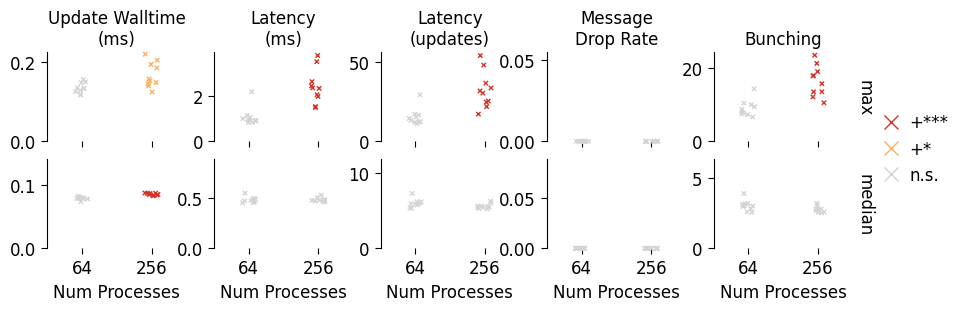

teeplots/2026-05-16-weak-scaling/col=metric+cpus_per_node=1+hue=significance+kind=strip+marker=x+num_simels_per_cpu=2048+row=kind+viz=catplot+x=num-processes+y=value+ext=.pdf
teeplots/2026-05-16-weak-scaling/col=metric+cpus_per_node=1+hue=significance+kind=strip+marker=x+num_simels_per_cpu=2048+row=kind+viz=catplot+x=num-processes+y=value+ext=.png


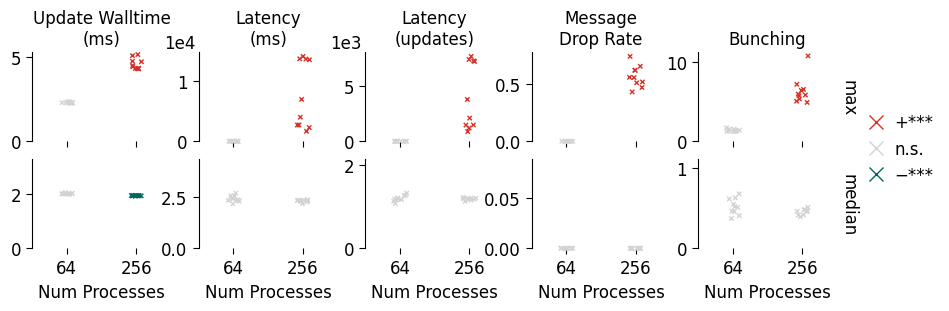

teeplots/2026-05-16-weak-scaling/col=metric+cpus_per_node=4+hue=significance+kind=strip+marker=x+num_simels_per_cpu=1+row=kind+viz=catplot+x=num-processes+y=value+ext=.pdf
teeplots/2026-05-16-weak-scaling/col=metric+cpus_per_node=4+hue=significance+kind=strip+marker=x+num_simels_per_cpu=1+row=kind+viz=catplot+x=num-processes+y=value+ext=.png


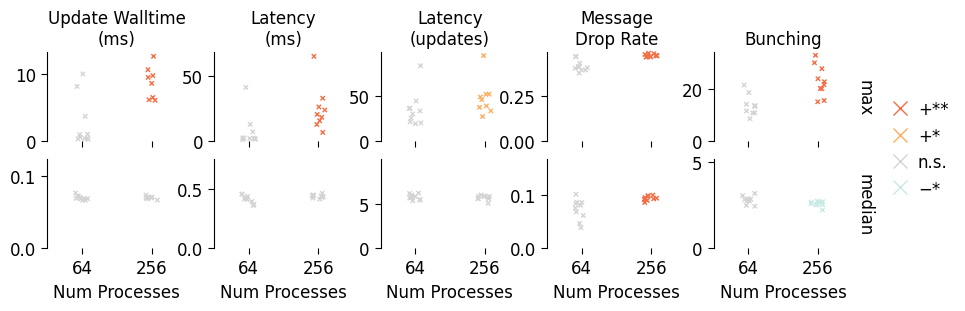

teeplots/2026-05-16-weak-scaling/col=metric+cpus_per_node=4+hue=significance+kind=strip+marker=x+num_simels_per_cpu=2048+row=kind+viz=catplot+x=num-processes+y=value+ext=.pdf
teeplots/2026-05-16-weak-scaling/col=metric+cpus_per_node=4+hue=significance+kind=strip+marker=x+num_simels_per_cpu=2048+row=kind+viz=catplot+x=num-processes+y=value+ext=.png


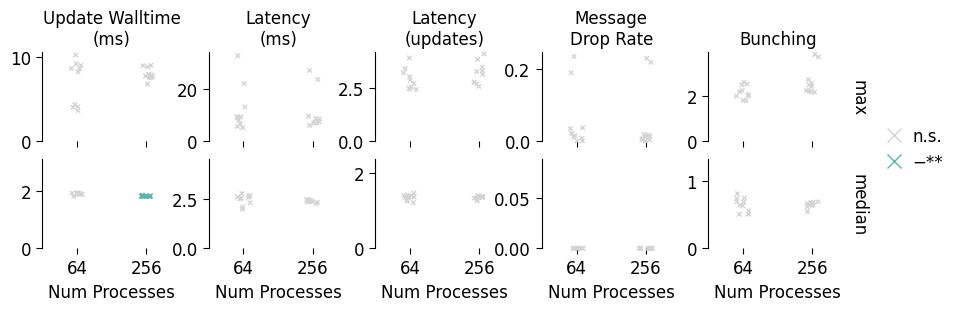

,Cpus Per Node,Num Simels Per Cpu,Metric,Kind,Median 64,Median 256,% Change,p-value,Significance
0,1,1,Bunching,max,8.477776,16.884863,99.166180,0.000583,+***
1,1,1,Bunching,median,3.023030,2.716998,-10.123348,0.075662,n.s.
2,1,1,Latency (ms),max,0.945182,2.356692,149.337467,0.000583,+***
3,1,1,Latency (ms),median,0.476849,0.479795,0.617831,0.677585,n.s.
4,1,1,Latency (updates),max,13.784093,31.019357,125.037344,0.000583,+***
...,...,...,...,...,...,...,...,...,...
35,4,2048,Latency (updates),median,1.353737,1.344668,-0.669965,0.623176,n.s.
36,4,2048,Message Drop Rate,max,0.018684,0.013270,-28.974611,0.623176,n.s.
37,4,2048,Message Drop Rate,median,0.000000,0.000000,NaN,1.000000,n.s.
38,4,2048,Update Walltime (ms),max,8.431901,7.818623,-7.273309,1.000000,n.s.


In [ ]:
_data_all = pd.concat([data_max, data_median], ignore_index=True).replace(
    {
        "Metric": {
            "Simstep Period Outlet (ms)": "Update Walltime\n(ms)",
            "Latency Simsteps Outlet": "Latency\n(updates)",
            "Latency Walltime Outlet (ms)": "Latency\n(ms)",
            "Delivery Clumpiness": "Bunching",
            "Delivery Failure Rate": "Message\nDrop Rate",
        },
    },
)

def _pvalue_to_sig(p, baseline, treatment):
    if p > 0.05:
        return "n.s."
    sign = "+" if np.median(treatment) >= np.median(baseline) else "−"
    if p < 0.001:
        return f"{sign}***"
    elif p < 0.01:
        return f"{sign}**"
    else:
        return f"{sign}*"

_sig_palette = {
    "+***": "#d73027",
    "+**": "#f46d43",
    "+*": "#fdae61",
    "n.s.": "lightgray",
    "−*": "#c7eae5",
    "−**": "#5ab4ac",
    "−***": "#01665e",
}
_sig_full_order = [
    "+***",
    "+**",
    "+*",
    "n.s.",
    "−*",
    "−**",
    "−***",
]

_stats_rows = []
for (_cpus, _simels), _cond_df in _data_all.groupby(
    ["Cpus Per Node", "Num Simels Per Cpu"]
):
    _cond_df = _cond_df.copy()
    _cond_df["Significance"] = "n.s."
    for (_metric, _kind), _grp in _cond_df.groupby(["Metric", "Kind"]):
        _baseline = _grp.loc[
            _grp["Num Processes"] == 64, "Value"
        ].to_numpy()
        _treatment = _grp.loc[
            _grp["Num Processes"] == 256, "Value"
        ].to_numpy()
        _n = min(len(_baseline), len(_treatment))
        _p = np.nan
        if _n < 1:
            _sig = "n.s."
        else:
            try:
                _, _p = scipy_stats.mannwhitneyu(_baseline, _treatment)
                _sig = _pvalue_to_sig(_p, _baseline, _treatment)
            except ValueError:
                _sig = "n.s."
        _mask = (
            (_cond_df["Metric"] == _metric)
            & (_cond_df["Kind"] == _kind)
            & (_cond_df["Num Processes"] == 256)
        )
        _cond_df.loc[_mask, "Significance"] = _sig
        _med_b = np.median(_baseline) if len(_baseline) else np.nan
        _med_t = np.median(_treatment) if len(_treatment) else np.nan
        _pct = (
            (_med_t - _med_b) / _med_b * 100
            if _med_b not in (0, np.nan) and not np.isnan(_med_b)
            else np.nan
        )
        _stats_rows.append(
            {
                "Cpus Per Node": _cpus,
                "Num Simels Per Cpu": _simels,
                "Metric": _metric.replace("\n", " "),
                "Kind": _kind,
                "Median 64": _med_b,
                "Median 256": _med_t,
                "% Change": _pct,
                "p-value": _p,
                "Significance": _sig,
            }
        )

    _hue_order = [
        _s
        for _s in _sig_full_order
        if _s in _cond_df["Significance"].unique()
    ]
    with tp.teed(
        sns.catplot,
        data=_cond_df,
        col="Metric",
        col_order=[
            "Update Walltime\n(ms)",
            "Latency\n(ms)",
            "Latency\n(updates)",
            "Message\nDrop Rate",
            "Bunching",
        ],
        row="Kind",
        x="Num Processes",
        order=[64, 256],
        y="Value",
        hue="Significance",
        hue_order=_hue_order,
        palette=_sig_palette,
        clip_on=False,
        kind="strip",
        linewidth=1,
        margin_titles=True,
        marker="x",
        s=10,
        sharey=False,
        dodge=False,
        teeplot_outattrs={
            "cpus_per_node": str(_cpus),
            "num_simels_per_cpu": str(_simels),
        },
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as _g:
        _g.figure.set_size_inches(9, 2.2)
        _g.set_titles(col_template="{col_name}", row_template="{row_name}")
        _g.set(ylim=(0, None), xlabel="Num Processes", ylabel="")
        plt.subplots_adjust(hspace=0.2, wspace=0.2)
        for _ax in _g.axes.flat:
            _ax.ticklabel_format(style="sci", axis="y", scilimits=(-4, 3))
            _ax.yaxis.get_offset_text().set_x(-0.25)
            _ax.yaxis.get_offset_text().set_y(0.5)
        for _ax in _g.axes[1, :].flat:
            _ax.set_ylim(1.6 * np.array(_ax.get_ylim()))
        sns.despine(fig=_g.figure, bottom=True)
        sns.move_legend(
            _g,
            loc="center right",
            bbox_to_anchor=(1.04, 0.5),
            frameon=False,
            title=None,
            markerscale=3,
            handletextpad=0.1,
        )

stats_df = pd.DataFrame(_stats_rows)
stats_df